# ✈️ Flights Dataset Analysis using Seaborn

## 📖 Project Overview

The Flights dataset is a classic time-series dataset available in Seaborn. It contains the monthly number of airline passengers from **1949 to 1960**.

In this project, we will use **Seaborn**, **Pandas**, and **Matplotlib** to perform Exploratory Data Analysis (EDA), visualize passenger trends over time, identify seasonal patterns, compare yearly and monthly performance, and extract meaningful business insights.

This analysis demonstrates how visualization techniques can be used to understand trends, seasonality, and growth in time-series data.

# 🎯 Objectives

By the end of this notebook, you will be able to:

- Load and explore the Flights dataset.
- Understand the structure of time-series data.
- Analyze yearly passenger growth.
- Compare monthly passenger trends.
- Identify seasonal patterns.
- Visualize trends using line plots and heatmaps.
- Draw meaningful business insights using Seaborn.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
sns.set_theme(style="whitegrid")

In [3]:
# Load the Flights dataset from Seaborn
df = sns.load_dataset("flights")

# Display the first five rows
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


# 📊 Dataset Overview

Before creating visualizations, let's understand the structure of the dataset.

We'll examine:

- Shape
- Data types
- Missing values
- Statistical summary

In [4]:
# Shape of dataset
df.shape

(144, 3)

In [5]:
# Display column names
df.columns

Index(['year', 'month', 'passengers'], dtype='str')

In [6]:
# Data types
df.dtypes

year             int64
month         category
passengers       int64
dtype: object

In [7]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [9]:
# Statistical summary
df.describe()

,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


In [10]:
# Display random samples
df.sample(5)

,year,month,passengers
103,1957,Aug,467
19,1950,Aug,170
76,1955,May,270
31,1951,Aug,199
96,1957,Jan,315


## 📌 Dataset Information

The Flights dataset contains **144 observations** and **3 columns**.

### Features

- **year** → Year of observation (1949–1960)
- **month** → Month of the year
- **passengers** → Total number of airline passengers

Each row represents the total number of passengers for a particular month in a given year.

# 🧹 Data Cleaning

Before performing analysis, it is important to verify the quality of the dataset.

We'll check for:

- Missing values
- Duplicate records
- Data consistency

In [11]:
# Check missing values
df.isnull().sum()

year          0
month         0
passengers    0
dtype: int64

In [12]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

### 📌 Observation

- The dataset contains **144 monthly records** spanning **12 years (1949–1960)**.
- No missing values are present in the dataset.
- No duplicate records were found.
- The dataset is clean and ready for exploratory data analysis.
- Each observation represents the passenger count for a specific month and year.

# ✈️ Total Passenger Distribution

Before analyzing trends over time, let's first understand how airline passenger counts are distributed across the dataset.

This visualization helps us analyze:

- Distribution of passenger counts
- Most common passenger ranges
- Data spread
- Skewness
- Overall variability

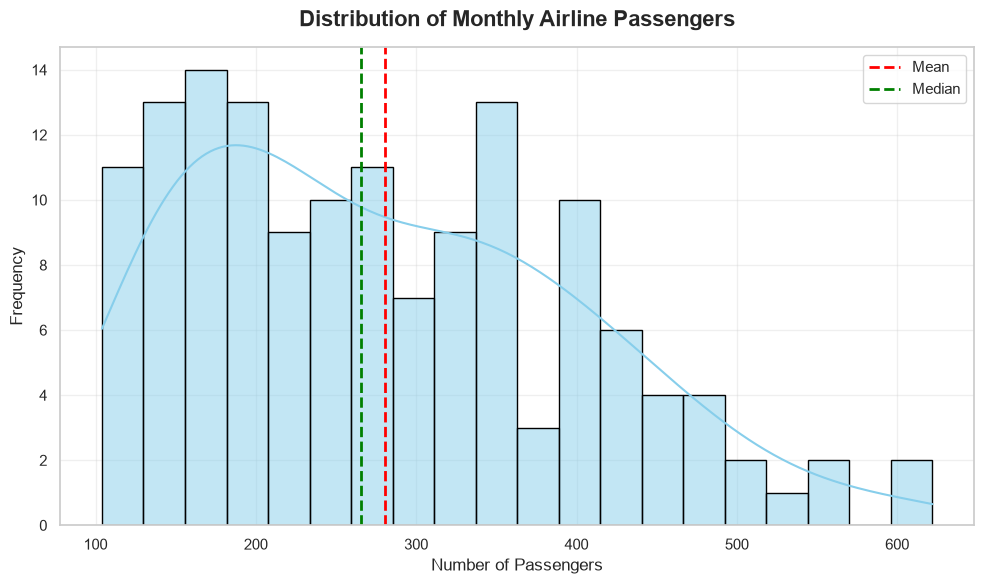

In [19]:
# This histogram shows the distribution
# of monthly airline passengers.

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="passengers",
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor="black"
)

plt.axvline(
    df["passengers"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.axvline(
    df["passengers"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label="Median"
)

plt.title(
    "Distribution of Monthly Airline Passengers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Passengers",
    fontsize=12
)

plt.ylabel(
    "Frequency",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- Monthly passenger counts range from approximately **100 to over 600 passengers**.
- The distribution is **right-skewed**, with a few months recording exceptionally high passenger numbers.
- Most monthly passenger counts fall between **150 and 350 passengers**.
- The mean is slightly higher than the median, indicating the presence of higher passenger values that pull the average upward.
- Overall, passenger traffic shows moderate variability across the dataset.

### 💡 Insight

The distribution indicates that while most months experience moderate passenger traffic, a small number of months record exceptionally high demand. This suggests seasonal travel peaks and long-term industry growth.

# 📈 Passenger Trend Over Time

Time-series analysis helps identify long-term trends in passenger traffic.

This visualization allows us to examine:

- Growth in passenger numbers over time
- Overall travel trends
- Long-term patterns

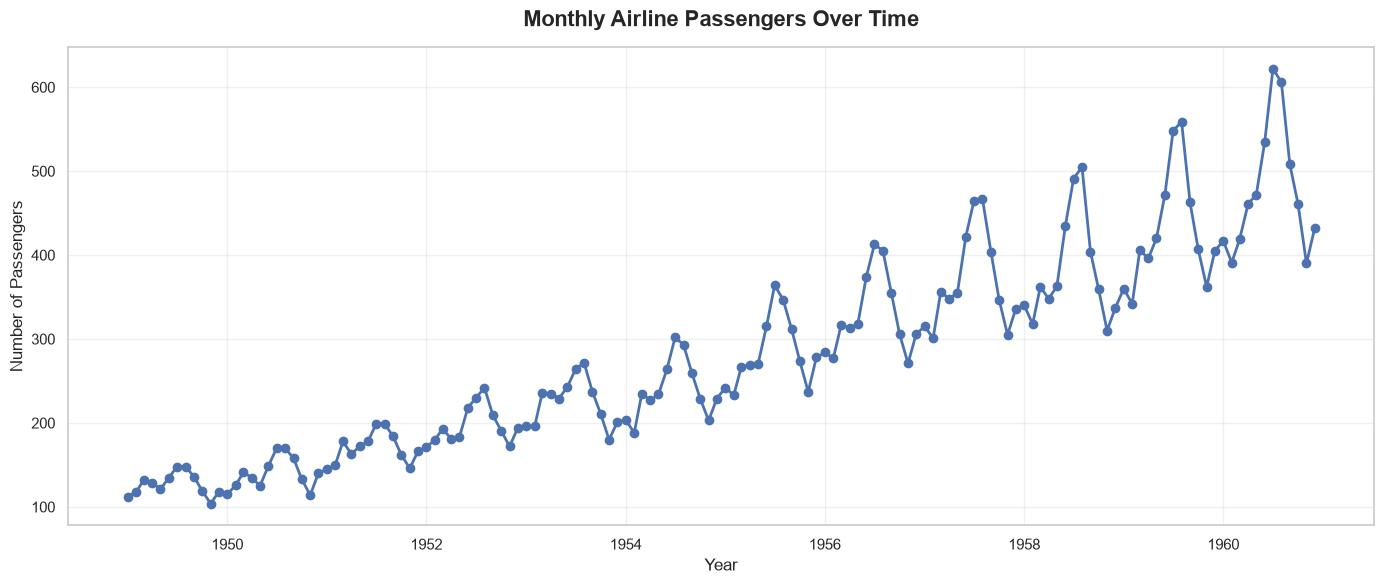

In [18]:
# Create a combined date column
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"].astype(str),
    format="%Y-%b"
)

plt.figure(figsize=(14,6))

plt.plot(
    df["date"],
    df["passengers"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Airline Passengers Over Time",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Year",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- Passenger traffic shows a strong and consistent upward trend from **1949 to 1960**.
- Seasonal peaks and declines repeat almost every year, indicating recurring travel patterns.
- The amplitude of seasonal peaks increases over time, meaning peak months become busier each year.
- The highest passenger count occurs near the end of the dataset (around **1960**).
- No long-term decline is observed throughout the study period.

### 💡 Insight

The airline industry experienced sustained growth during this period. The recurring seasonal peaks indicate predictable travel demand, while the increasing trend reflects the rising popularity of air travel year after year.

# 📅 Average Passengers by Month

Different months experience different levels of passenger traffic.

Let's compare the average number of passengers across all months.

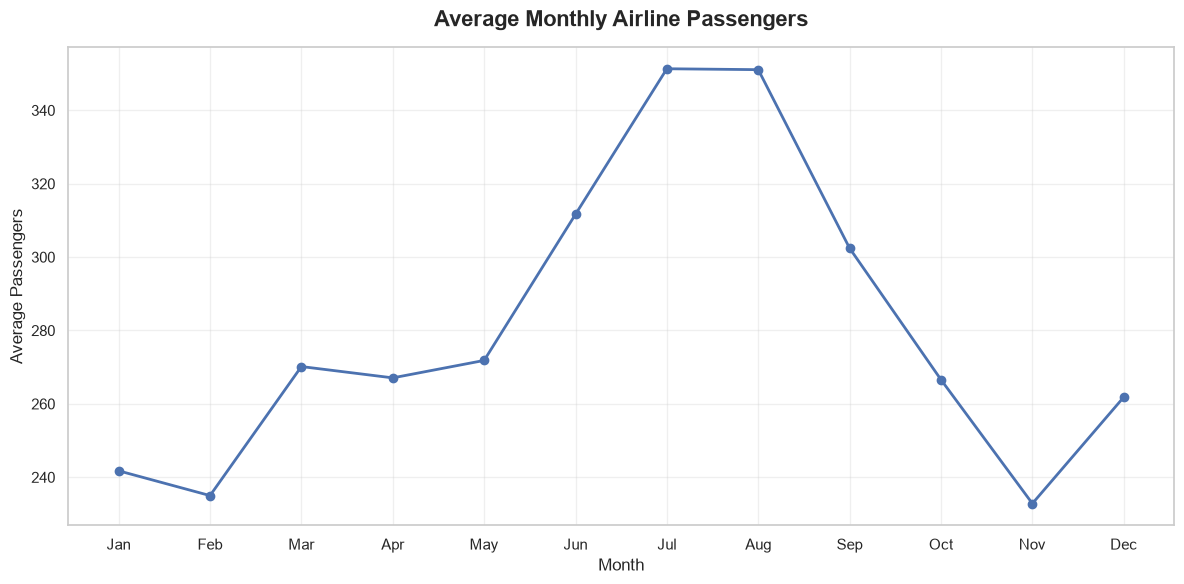

In [15]:
monthly_avg = df.groupby("month")["passengers"].mean()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Average Monthly Airline Passengers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Average Passengers",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- Passenger traffic gradually increases from **January** toward the middle of the year.
- **July** and **August** record the highest average number of passengers.
- Passenger numbers begin to decline after August.
- **November** has the lowest average passenger count.
- The monthly averages clearly demonstrate a recurring seasonal travel pattern.

### 💡 Insight

Passenger demand is highest during the summer months, likely due to vacations and holiday travel. Airlines can use this information to optimize flight schedules, staffing, and seat availability during peak seasons.

# 📆 Average Passengers by Year

Comparing yearly averages helps us understand long-term growth in passenger traffic.

This visualization highlights how airline demand changed over time.

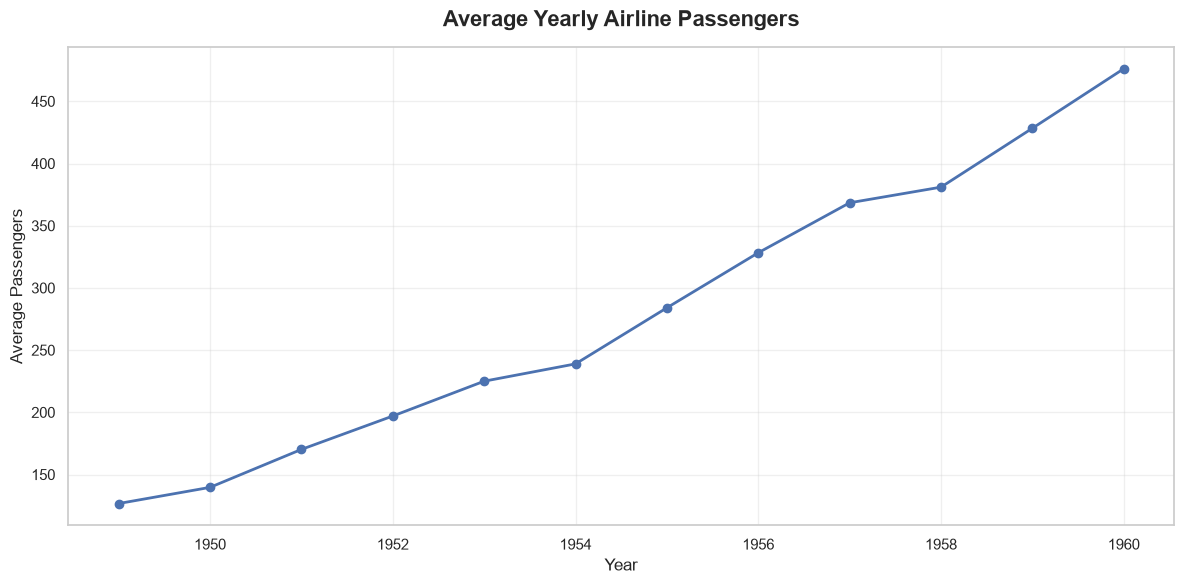

In [16]:
yearly_avg = df.groupby("year")["passengers"].mean()

plt.figure(figsize=(12,6))

plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Average Yearly Airline Passengers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Year",
    fontsize=12
)

plt.ylabel(
    "Average Passengers",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- The average number of passengers increases steadily every year from **1949 to 1960**.
- No year shows a noticeable decrease in average passenger traffic.
- Growth becomes more pronounced after **1955**, indicating accelerated expansion.
- **1960** records the highest average passenger count.
- The overall trend reflects continuous long-term growth in airline travel.

### 💡 Insight

The steady increase in yearly passenger averages suggests continuous expansion of the airline industry. Rising passenger demand over the years indicates growing public adoption of air travel and increasing market opportunities for airlines.

# 🌍 Seasonal Analysis

Air travel demand often follows seasonal patterns due to holidays, vacations, and weather conditions.

In this section, we'll analyze how passenger traffic changes across different months and years to identify recurring seasonal trends.

# 📅 Monthly Passenger Comparison

Let's compare the total number of passengers for each month across the entire dataset.

This visualization helps identify which months consistently experience higher or lower passenger traffic.

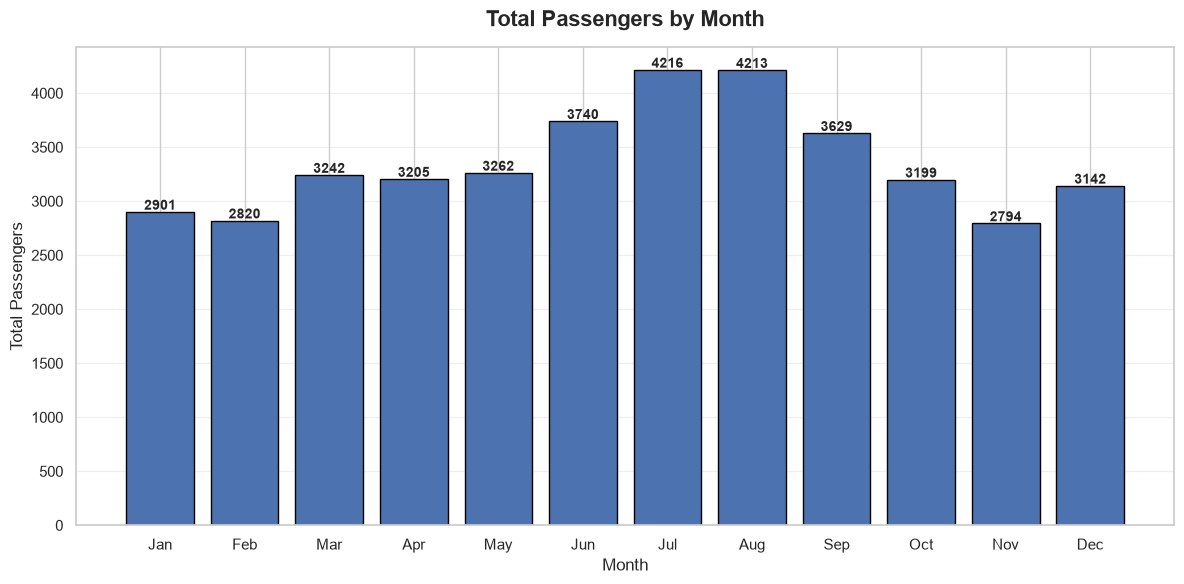

In [20]:
# Calculate total passengers for each month
monthly_passengers = (
    df.groupby("month", observed=True)["passengers"]
      .sum()
)

plt.figure(figsize=(12,6))

plt.bar(
    monthly_passengers.index,
    monthly_passengers.values,
    edgecolor="black"
)

# Add value labels
for i, value in enumerate(monthly_passengers.values):
    plt.text(
        i,
        value + 20,
        f"{value}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Total Passengers by Month",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month", fontsize=12)

plt.ylabel("Total Passengers", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- Passenger traffic gradually increases from **January** and reaches its peak during **July (4,216 passengers)** and **August (4,213 passengers)**.
- After August, passenger numbers begin to decline steadily until **November**, which records the lowest total passenger count (**2,794 passengers**).
- Passenger traffic rises slightly again in **December**, likely due to holiday travel.
- Overall, the chart clearly demonstrates a recurring seasonal travel pattern.

### 💡 Insight

The highest passenger demand occurs during the summer months (July and August), suggesting that vacation and holiday seasons significantly influence airline travel. Airlines should prepare for increased demand during these months by scheduling additional flights and allocating more operational resources.

# 📈 Passenger Trend by Year

Instead of viewing one continuous time series, let's compare passenger trends separately for each year.

This helps us understand how seasonal patterns evolved over time.

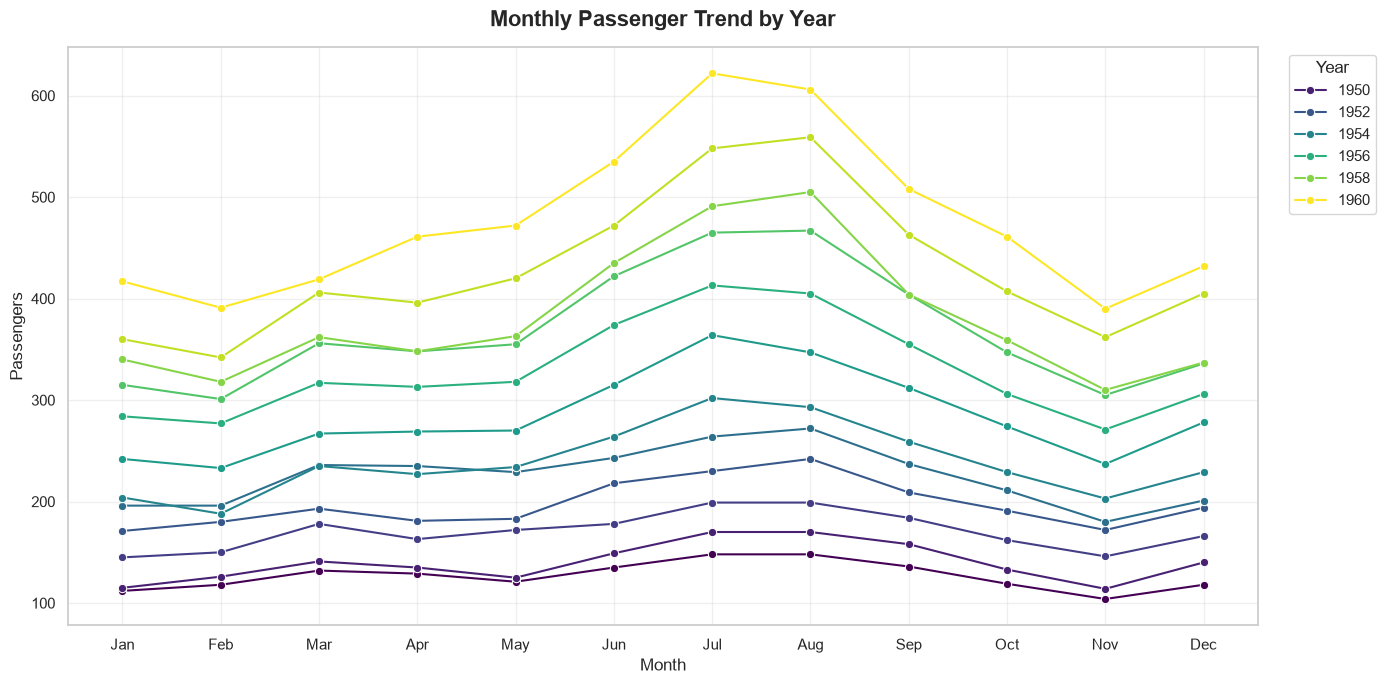

In [21]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=df,
    x="month",
    y="passengers",
    hue="year",
    marker="o",
    palette="viridis"
)

plt.title(
    "Monthly Passenger Trend by Year",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month", fontsize=12)

plt.ylabel("Passengers", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(
    title="Year",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

### 📌 Observation

- Every year follows a similar seasonal pattern, with passenger numbers increasing from the beginning of the year, peaking in **July–August**, and declining afterward.
- Passenger counts consistently increase from one year to the next, indicating long-term growth in airline travel.
- Seasonal peaks become more pronounced in later years, showing stronger demand during peak travel months.
- No year shows a long-term decline in passenger traffic.

### 💡 Insight

The consistent seasonal pattern indicates predictable customer behavior, allowing airlines to forecast demand accurately. The steady upward shift across years reflects continuous industry growth and increasing popularity of air travel.

# 🔥 Passenger Heatmap

A heatmap provides one of the clearest ways to visualize seasonal trends.

Rows represent years, columns represent months, and colors indicate passenger volume.

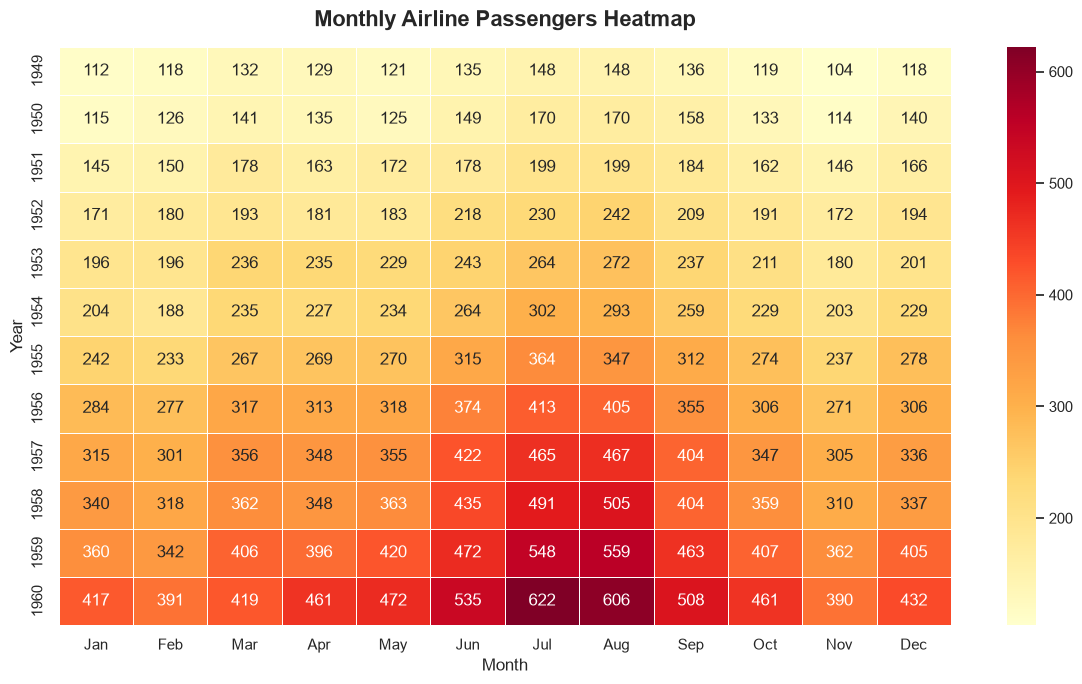

In [22]:
# Create pivot table
pivot = df.pivot(
    index="year",
    columns="month",
    values="passengers"
)

plt.figure(figsize=(12,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title(
    "Monthly Airline Passengers Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month", fontsize=12)

plt.ylabel("Year", fontsize=12)

plt.tight_layout()

plt.show()

### 📌 Observation

- Passenger volumes increase steadily from **1949** to **1960**, as shown by the transition from lighter to darker colors.
- **July** and **August** consistently record the highest passenger counts across almost all years.
- Earlier years have relatively lower passenger traffic, while later years experience significantly higher demand.
- The heatmap clearly highlights both annual growth and recurring seasonal peaks.

### 💡 Insight

The heatmap effectively visualizes two important business patterns: sustained long-term growth and strong seasonal demand. Such insights can help airlines forecast passenger traffic, optimize capacity planning, and improve operational efficiency.

# 📦 Monthly Passenger Distribution

A box plot helps us understand the distribution of passenger counts for each month across all years.

It highlights variability, median values, and potential outliers.

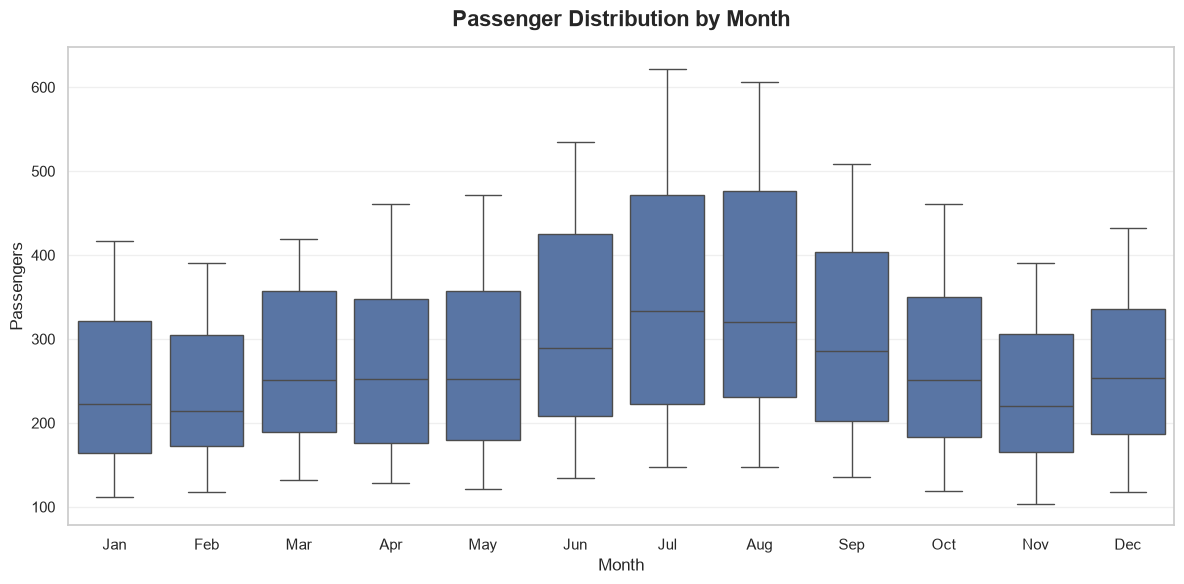

In [33]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="month",
    y="passengers"
)

plt.title(
    "Passenger Distribution by Month",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month", fontsize=12)

plt.ylabel("Passengers", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- Passenger counts vary across different months, with **July** and **August** showing the highest median values.
- Summer months also exhibit greater variability, indicating larger fluctuations in passenger demand.
- Winter months generally have lower median passenger counts and a narrower spread.
- No extreme outliers are observed, suggesting consistent seasonal patterns over the years.

### 💡 Insight

The box plot shows that passenger demand is not only higher during the summer months but also more variable. Airlines should remain flexible during peak seasons to accommodate changing travel demand.

# 🎻 Monthly Passenger Distribution

The violin plot combines a box plot with a density plot, providing a detailed view of passenger distributions for each month.

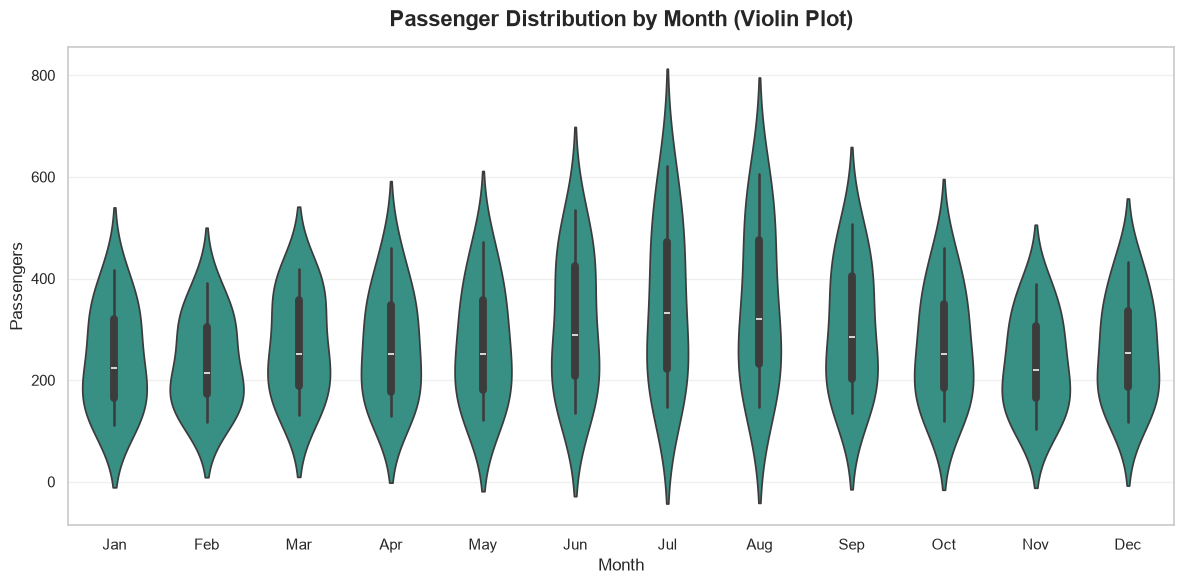

In [29]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="month",
    y="passengers",
    color="#2A9D8F"
)

plt.title(
    "Passenger Distribution by Month (Violin Plot)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month", fontsize=12)

plt.ylabel("Passengers", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- The violin plots reveal that passenger distributions become wider during **June**, **July**, and **August**, indicating higher variability in demand.
- **July** has the broadest distribution, reflecting both high passenger counts and greater variation across years.
- Lower-demand months, such as **January**, **February**, and **November**, have more compact distributions.
- The density patterns confirm the recurring seasonal nature of airline passenger traffic.

### 💡 Insight

The violin plot provides a detailed view of passenger distributions, showing that peak travel months experience both higher demand and greater variability. This information is valuable for forecasting passenger loads and optimizing airline operations.

# 📈 Relationship Analysis

Understanding relationships between variables is one of the most important steps in Exploratory Data Analysis (EDA).

In this section, we'll examine how airline passenger traffic changes over time and explore the relationship between different variables using scatter plots, regression plots, and other visualizations.

These analyses help identify long-term growth patterns and trends in airline passenger demand.

# 🔹 Passenger Growth Over the Years

A scatter plot helps visualize how passenger numbers change over time.

It allows us to identify growth patterns, clusters, and potential trends in airline passenger traffic.

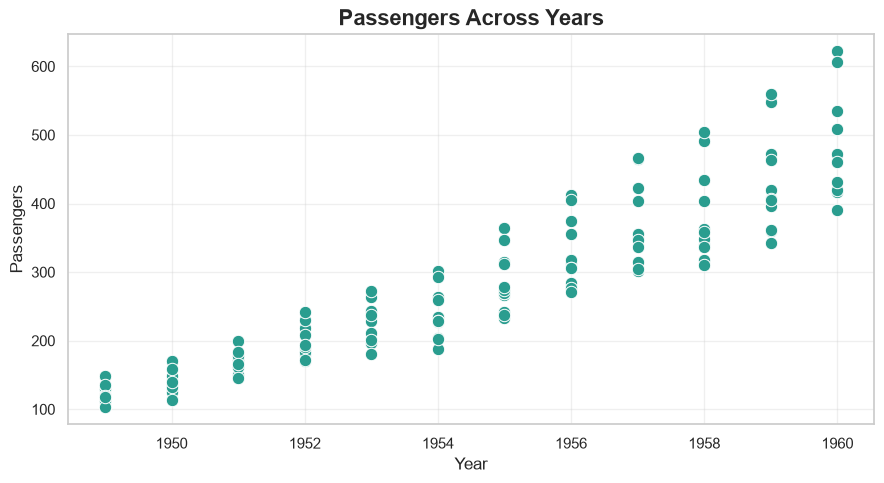

In [34]:
plt.figure(figsize=(9,5))

sns.scatterplot(
    data=df,
    x="year",
    y="passengers",
    s=80,
    color="#2A9D8F"
)

plt.title(
    "Passengers Across Years",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- Passenger numbers show a clear upward trend from **1949 to 1960**.
- Each year records higher passenger counts than the previous year.
- The spread of passenger values increases over time, indicating growing seasonal variation.
- The highest passenger counts are observed in the final years of the dataset, especially **1959** and **1960**.
- No long-term decline in passenger traffic is visible.

### 💡 Insight

The scatter plot indicates continuous growth in airline passenger demand throughout the observed period. This steady increase suggests the airline industry expanded consistently, making future passenger growth relatively predictable.

# 🔹 Regression Analysis

A regression plot combines a scatter plot with a best-fit regression line.

It helps us determine whether passenger traffic has increased or decreased over time and whether the relationship is approximately linear.

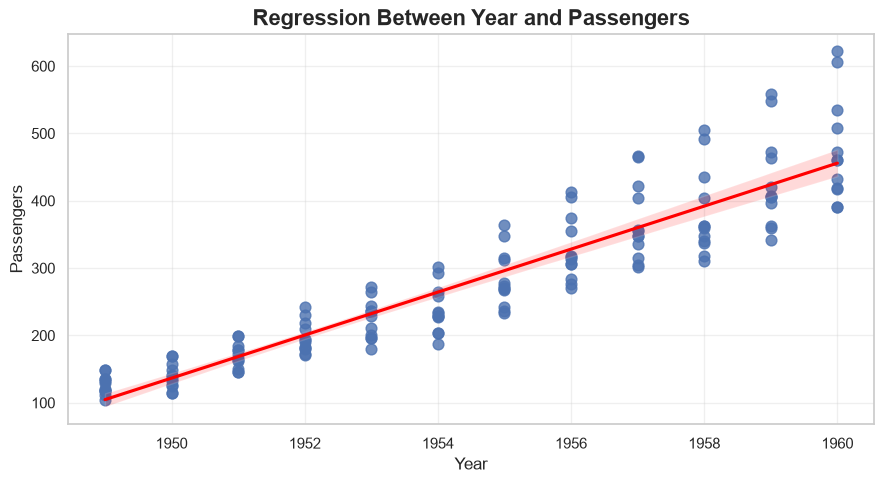

In [35]:
plt.figure(figsize=(9,5))

sns.regplot(
    data=df,
    x="year",
    y="passengers",
    scatter_kws={
        "s":60
    },
    line_kws={
        "color":"red"
    }
)

plt.title(
    "Regression Between Year and Passengers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- The regression line has a strong positive slope, indicating that passenger numbers increase over time.
- Most data points are distributed close to the regression line, showing a strong positive relationship between year and passenger count.
- Passenger variability becomes larger in later years due to increasing seasonal demand.
- There are no significant deviations from the overall upward trend.

### 💡 Insight

The regression analysis confirms that passenger traffic has grown consistently over the years. The strong positive relationship suggests that time is an important factor influencing airline passenger growth and supports long-term demand forecasting.

# 🔹 Passenger Distribution by Month Across Years

By coloring the scatter plot using months, we can observe seasonal patterns and determine whether certain months consistently record higher passenger traffic.

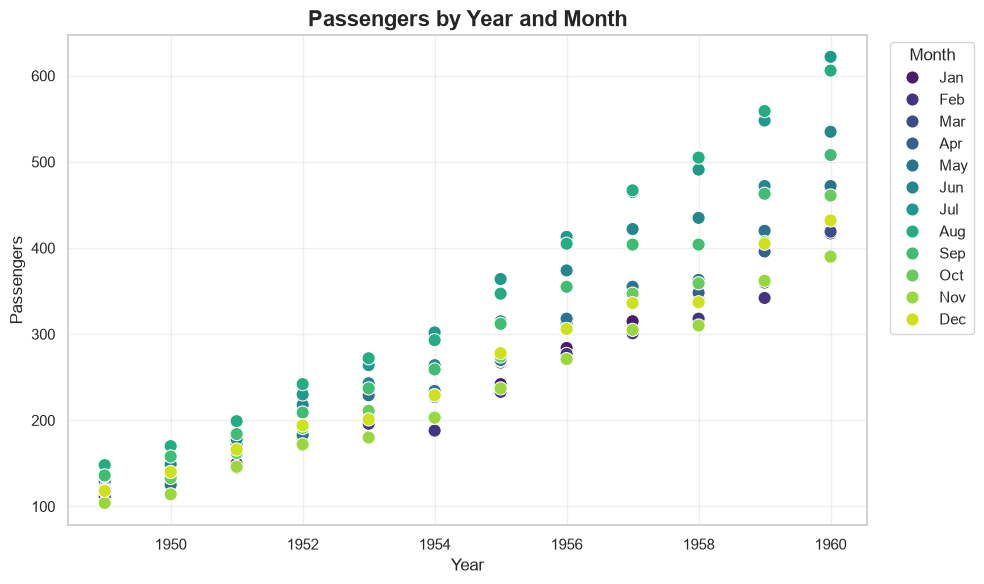

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="year",
    y="passengers",
    hue="month",
    palette="viridis",
    s=90
)

plt.title(
    "Passengers by Year and Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.legend(
    title="Month",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 📌 Observation

- Passenger numbers increase steadily across all months from **1949** to **1960**.
- Mid-year months, particularly **July** and **August**, consistently record the highest passenger counts.
- Winter months generally have lower passenger volumes compared to summer months.
- Seasonal patterns remain consistent across all years while overall passenger demand continues to grow.
- The highest passenger counts are recorded during the summer months in the later years of the dataset.

### 💡 Insight

The visualization highlights two key trends: strong long-term growth and recurring seasonal demand. Airlines can use these patterns to forecast peak travel periods, optimize flight schedules, and allocate resources more efficiently during high-demand months.

# 🔹 Relationship Summary

These visualizations provide valuable insights into airline passenger trends.

They reveal long-term growth, seasonal travel patterns, and the consistency of passenger demand across multiple years.

Such analyses are widely used in forecasting, capacity planning, and business decision-making within the airline industry.

## 📌 Key Business Insights

- Airline passenger traffic increased consistently from **1949 to 1960**, indicating strong long-term industry growth.
- Passenger demand follows a clear seasonal pattern, with **July and August** consistently recording the highest passenger volumes.
- Passenger numbers begin to rise during spring, peak in the summer months, and gradually decline toward the end of the year.
- Summer months exhibit greater variability in passenger traffic, reflecting increased travel demand during vacation seasons.
- The regression analysis confirms a strong positive relationship between **Year** and **Passenger Count**, suggesting continuous market expansion.
- Heatmap analysis highlights both recurring seasonal demand and sustained yearly growth.
- The airline industry can use these seasonal patterns for demand forecasting, fleet management, pricing strategies, and resource allocation.

# 📌 Key Takeaways

Throughout this project, we learned how to:

- Load and explore the Flights dataset using Pandas.
- Perform exploratory data analysis (EDA).
- Analyze passenger distributions using histograms.
- Visualize long-term passenger growth using line plots.
- Compare monthly and yearly passenger trends.
- Identify seasonal travel patterns using bar charts, box plots, violin plots, and heatmaps.
- Examine relationships between variables using scatter plots and regression analysis.
- Draw meaningful business insights from time-series data using Seaborn and Matplotlib.

# ✅ Conclusion

This project explored the **Flights dataset** using Exploratory Data Analysis (EDA) techniques with **Pandas**, **Matplotlib**, and **Seaborn**.

Throughout the analysis, we examined passenger distributions, long-term growth trends, seasonal travel patterns, and relationships between different time-based features. Multiple visualizations—including histograms, line plots, scatter plots, box plots, violin plots, and heatmaps—helped uncover meaningful insights about airline passenger behavior.

The analysis revealed that airline passenger traffic increased steadily from **1949 to 1960**, with consistent seasonal peaks during the summer months, particularly **July** and **August**. Regression analysis further confirmed a strong positive relationship between time and passenger growth.

Overall, this project demonstrates how data visualization and exploratory analysis can transform raw time-series data into valuable business insights, supporting better forecasting, resource planning, and strategic decision-making in the airline industry.

# 💡 Best Practices

When performing time-series exploratory data analysis:

- Understand the dataset before creating visualizations.
- Ensure date columns are correctly formatted.
- Analyze both long-term trends and seasonal patterns.
- Compare multiple visualizations before drawing conclusions.
- Choose visualization types that best represent the data.
- Clearly label axes, titles, and legends for better readability.
- Use consistent colors and themes throughout the notebook.
- Validate business insights using multiple charts instead of relying on a single visualization.

# 🙏 Thank You

Thank you for exploring this **Flights Dataset Analysis** project!

This notebook demonstrated how Exploratory Data Analysis (EDA) can uncover meaningful trends, seasonal patterns, and business insights from airline passenger data.

Through visualizations created with **Matplotlib** and **Seaborn**, we explored passenger distributions, long-term growth, seasonal demand, and relationships between variables.

I hope this project provides a clear understanding of time-series data visualization and serves as a useful learning resource.

⭐ Thank you for reading, and happy learning!